# WORK 4 : Real LIGO Noise Analysis using Vanilla and Joint GARCH

This notebook performs parameter estimation on a toy gravitational-wave chirp injected into real LIGO O3b noise. The data are whitened using the detector PSD, a transient glitch is injected, and the performance of the Vanilla Gaussian likelihood is compared with the Joint GARCH likelihood.

---

## Cell 1 : Load Real LIGO Noise

- Load the LIGO O3b strain data from the HDF5 file.
- Replace any invalid (NaN) samples if present.
- Display basic information about the dataset.
- Plot the first 10 seconds of the detector noise.


✓ LIGO noise loaded successfully.
✓ No NaNs found.
Sampling frequency : 4096 Hz
Samples            : 16777216
Duration           : 4096.0 s


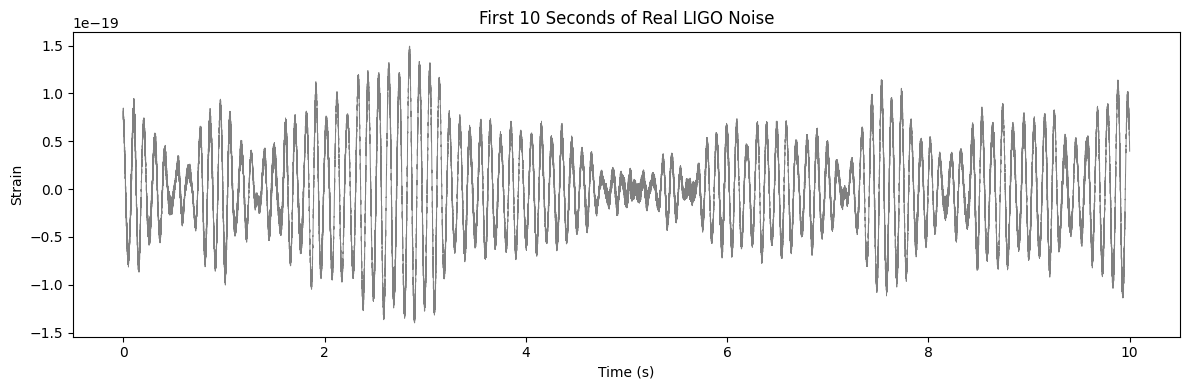

In [26]:
# =====================================================
# Load Real LIGO Noise
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import h5py

# -----------------------------------------------------
# Load LIGO O3b Noise
# -----------------------------------------------------

hdf5_filename = "H-H1_LIGO_O3B_NOISE_ONLY.hdf5"

with h5py.File(hdf5_filename, "r") as f:
    raw_long_strain = f["strain"]["Strain"][:]
    fs = 4096.0

print("✓ LIGO noise loaded successfully.")

# -----------------------------------------------------
# Replace NaNs (if any)
# -----------------------------------------------------

bad_mask = ~np.isfinite(raw_long_strain)
if np.any(bad_mask):
    print(f"Found {np.sum(bad_mask)} invalid samples.")
    raw_long_strain[bad_mask] = 0.0
    pad = 128
    N_total = len(raw_long_strain)
    for idx in np.where(bad_mask)[0]:
        left = max(0, idx-pad)
        right = min(N_total, idx+pad+1)
        if idx-left > 0:
            raw_long_strain[left:idx] *= np.sin(
                np.linspace(0, np.pi/2, idx-left))
        if right-(idx+1) > 0:
            raw_long_strain[idx+1:right] *= np.cos(
                np.linspace(0, np.pi/2, right-(idx+1)))
else:
    print("✓ No NaNs found.")

# -----------------------------------------------------
# Information
# -----------------------------------------------------

duration = len(raw_long_strain)/fs

print(f"Sampling frequency : {fs:.0f} Hz")
print(f"Samples            : {len(raw_long_strain)}")
print(f"Duration           : {duration:.1f} s")

# -----------------------------------------------------
# Plot first 10 seconds
# -----------------------------------------------------

time = np.arange(len(raw_long_strain))/fs

plt.figure(figsize=(12,4))
plt.plot(time[:10*int(fs)],raw_long_strain[:10*int(fs)],color="gray",lw=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("First 10 Seconds of Real LIGO Noise")
plt.tight_layout()
plt.show()

## Cell 2 : Select Analysis Segment and Estimate PSD

- Select a 10-second analysis segment from the LIGO data.
- Use the remaining data as off-source noise.
- Estimate the Power Spectral Density (PSD) using Welch's method.
- Precompute the quantities required for spectral whitening.


In [27]:
# =====================================================
# Select Analysis Segment + Estimate PSD
# =====================================================

from scipy.signal import welch

# -----------------------------------------------------
# Analysis segment
# -----------------------------------------------------

analysis_duration = 10.0
N_analysis = int(analysis_duration * fs)
start = 200000
analysis_noise = raw_long_strain[start:start+N_analysis]
offsource_data = raw_long_strain[:-N_analysis]
t = np.arange(N_analysis) / fs

print(f"Analysis samples  : {len(analysis_noise)}")
print(f"Off-source samples: {len(offsource_data)}")

# =====================================================
# Estimate PSD using Welch
# =====================================================

f_w, psd_seed = welch(offsource_data,fs=fs,nperseg=2*int(fs),scaling="density")
fft_freq = np.fft.rfftfreq(N_analysis, d=1/fs)
psd_historical_interp = np.interp(fft_freq,f_w,psd_seed)

print("PSD estimated successfully.")

# =====================================================
# Precompute Whitening Quantities
# =====================================================

sqrt_psd = np.sqrt(psd_historical_interp)

sqrt_psd[~np.isfinite(sqrt_psd)] = 1e-20
sqrt_psd[sqrt_psd < 1e-20] = 1e-20

whitening_norm = np.sqrt(fs * N_analysis / 2.0)

freq_axis = np.fft.rfftfreq(N_analysis, d=1/fs)
low_freq_mask = freq_axis < 20.0

print("Whitening quantities precomputed.")

Analysis samples  : 40960
Off-source samples: 16736256
PSD estimated successfully.
Whitening quantities precomputed.


## Cell 3 : Whitening, Chirp Generation and Signal Injection

- Define the spectral whitening function.
- Generate the toy chirp waveform.
- Scale the waveform to the desired SNR.
- Generate a sine-Gaussian glitch.
- Inject the chirp and glitch into the real LIGO noise.
- Plot the resulting detector data.


Unit-amplitude whitened SNR = 9.29609184791924e+19
Signal amplitude = 8.605766951184602e-20
Injected SNR = 7.999999999999999


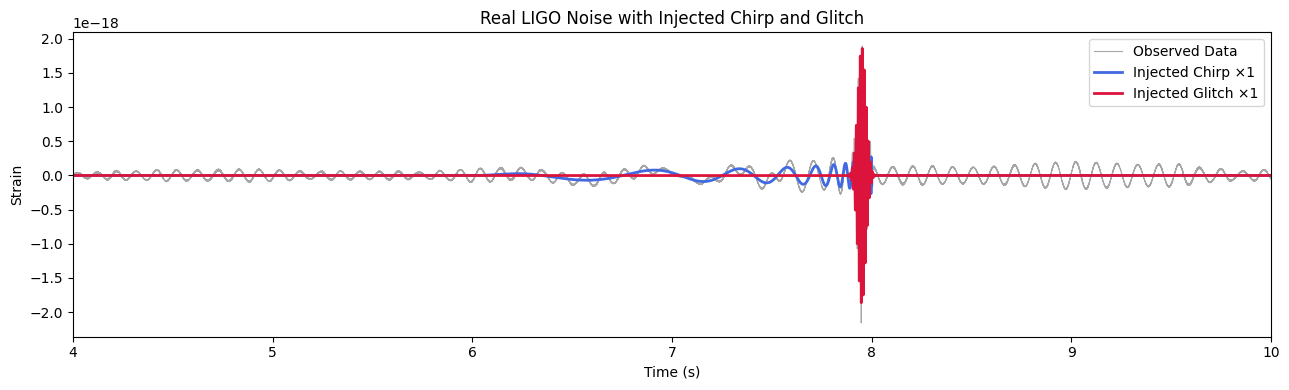

In [36]:
# =====================================================
# Whitening + Chirp Generation + Signal Injection
# =====================================================

from scipy.fft import rfft, irfft
from numba import njit

# =====================================================
# Whitening Function
# =====================================================

def spectral_whiten(x):
    X = rfft(x)
    X /= sqrt_psd
    X /= whitening_norm
    X[low_freq_mask] = 0.0
    return irfft(X, n=len(x)) * np.sqrt(len(x))

# =====================================================
# True Signal Parameters
# =====================================================

cr_true = 25.0
tc_true = 8.0

target_snr = 8.0

# =====================================================
# Toy Chirp Model
# =====================================================

@njit
def generate_chirp(t, A, cr, tc):
    N = len(t)
    h = np.zeros(N)
    start = tc - 2.0
    taper_fraction = 0.2
    taper_time = taper_fraction * 2.0
    for i in range(N):
        if start < t[i] < tc:
            tau = tc - t[i]
            phase = -2.0 * cr * (tau + 0.02)**(-0.25)
            amplitude = A / np.sqrt(tau + 0.1)
            value = amplitude * np.sin(phase)
            x = t[i] - start
            if x < taper_time:
                w = 0.5 * (1.0 - np.cos(np.pi*x/taper_time))
                value *= w
            h[i] = value
    return h

# =====================================================
# Compute Signal Amplitude
# =====================================================

signal_unit = generate_chirp(t,1.0,cr_true,tc_true)
signal_unit_white = spectral_whiten(signal_unit)

snr_unit = np.sqrt(np.sum(signal_unit_white**2))
print("Unit-amplitude whitened SNR =", snr_unit)

A_true = target_snr / snr_unit
print("Signal amplitude =", A_true)

# =====================================================
# Generate True Chirp
# =====================================================

h_true = generate_chirp(t,A_true,cr_true,tc_true)
h_true_white = spectral_whiten(h_true)

snr_check = np.sqrt(np.sum(h_true_white**2))
print("Injected SNR =", snr_check)

# =====================================================
# Sine-Gaussian Glitch
# =====================================================

glitch_tc = 7.95
glitch_tau = 0.020
glitch_f0 = 100.0

glitch_amp = 7*np.max(np.abs(h_true))

glitch = (glitch_amp* np.exp(-(t-glitch_tc)**2/(2*glitch_tau**2))* np.sin(2*np.pi*glitch_f0*(t-glitch_tc)))

# =====================================================
# Detector Data
# =====================================================

data = analysis_noise + h_true + glitch

# =====================================================
# Plot
# =====================================================

display_scale = 1

plt.figure(figsize=(13,4))
plt.plot(t,data,color="gray",lw=0.8,alpha=0.7,label="Observed Data")
plt.plot(t,display_scale*h_true,color="royalblue",lw=2,label=f"Injected Chirp ×{display_scale}")
plt.plot(t,display_scale*glitch,color="crimson",lw=2,label=f"Injected Glitch ×{display_scale}")
plt.xlim(4,10)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Real LIGO Noise with Injected Chirp and Glitch")
plt.legend()
plt.tight_layout()
plt.show()

## Cell 4 : Whiten the Data

- Whiten the detector data, injected signal and glitch.
- Select the analysis window around the signal.
- Prepare the whitened data for parameter estimation.


In [34]:
# =====================================================
# Whiten Data, Chirp and Glitch
# =====================================================

data_white = spectral_whiten(data)
signal_white = spectral_whiten(h_true)
glitch_white = spectral_whiten(glitch)

print("Whitened data mean :", np.mean(data_white))
print("Whitened data std  :", np.std(data_white))

# =====================================================
# Analysis Window
# =====================================================

t_start = tc_true - 2.05
t_end   = tc_true + 0.05

mask = (t >= t_start) & (t <= t_end)

t_analysis = t[mask]

data_analysis    = data_white[mask]
signal_analysis  = signal_white[mask]
glitch_analysis  = glitch_white[mask]


Whitened data mean : -1.7347234759768072e-19
Whitened data std  : 0.4958441740419667


## Cell 5 : Vanilla Gaussian Parameter Estimation

- Define the Gaussian likelihood, prior and posterior.
- Run MCMC to estimate the chirp rate (`cr`) and coalescence time (`tc`).
- Generate the corner plot.
- Compute the estimated parameters and acceptance fraction.


Running Vanilla MCMC...


100%|███████████████████████████████████████| 5000/5000 [03:54<00:00, 21.28it/s]


Finished.
Number of samples: 6400


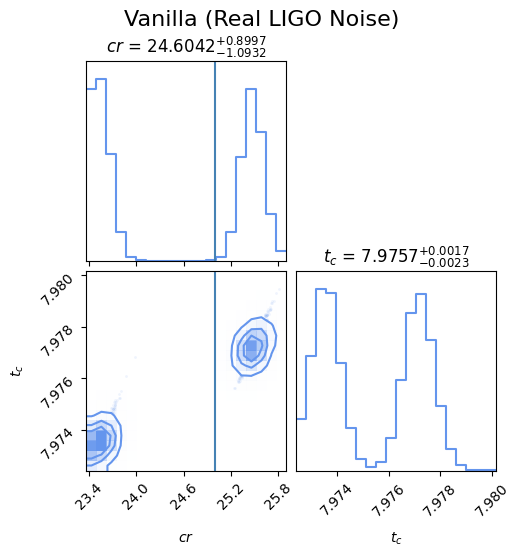


Vanilla Results
-------------------------
cr = 24.5076 ± 0.9716
tc = 7.975393 ± 0.001856

Acceptance fraction = 0.3254875


In [35]:
# =====================================================
# Vanilla Gaussian Likelihood
# =====================================================

import emcee
import corner

# -----------------------------------------------------
# Gaussian Log-Likelihood
# -----------------------------------------------------

def vanilla_log_likelihood(cr, tc):
    model = generate_chirp(t,A_true,cr,tc)
    model_white = spectral_whiten(model)
    model_analysis = model_white[mask]
    residual = data_analysis - model_analysis
    logL = (-0.5 * len(residual) * np.log(2*np.pi)-0.5 * np.sum(residual**2))
    return logL

# -----------------------------------------------------
# Prior
# -----------------------------------------------------

def log_prior(theta):
    cr, tc = theta
    if (
        23.0 < cr < 27.0
        and 7.8 < tc < 8.2
    ):
        return 0.0
    return -np.inf

# -----------------------------------------------------
# Posterior
# -----------------------------------------------------

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    cr, tc = theta
    return lp + vanilla_log_likelihood(cr, tc)

# =====================================================
# Vanilla MCMC
# =====================================================

ndim = 2
nwalkers = 32

initial = np.array([cr_true,tc_true])

pos = initial + np.array([
    0.01*np.random.randn(nwalkers),
    0.0005*np.random.randn(nwalkers)
]).T

sampler = emcee.EnsembleSampler(nwalkers,ndim,log_probability)

print("Running Vanilla MCMC...")

sampler.run_mcmc(pos,5000,progress=True)

print("Finished.")

samples = sampler.get_chain(discard=1000,thin=20,flat=True)

print("Number of samples:", len(samples))

# =====================================================
# Corner Plot
# =====================================================

figure = corner.corner(samples,labels=[r"$cr$", r"$t_c$"],truths=[cr_true, tc_true],show_titles=True,smooth=1.0,smooth1d=1.0,
    color="cornflowerblue",title_fmt=".4f")
figure.suptitle("Vanilla (Real LIGO Noise)",fontsize=16,y=1.02)
plt.show()

# =====================================================
# Results
# =====================================================

cr_est_vanilla = np.mean(samples[:,0])
tc_est_vanilla = np.mean(samples[:,1])

cr_std_vanilla = np.std(samples[:,0])
tc_std_vanilla = np.std(samples[:,1])

print("\nVanilla Results")
print("-------------------------")
print(f"cr = {cr_est_vanilla:.4f} ± {cr_std_vanilla:.4f}")
print(f"tc = {tc_est_vanilla:.6f} ± {tc_std_vanilla:.6f}")

print("\nAcceptance fraction =", np.mean(sampler.acceptance_fraction))

## Cell 6 : Joint GARCH Parameter Estimation

- Define the GARCH(1,1) likelihood with time-varying variance.
- Sample `(cr, tc, ω, α, β)` simultaneously using MCMC.
- Generate the posterior corner plot.
- Estimate the GARCH parameters.
- Compare the Vanilla and Joint GARCH parameter estimates.


Running Joint GARCH MCMC...


100%|█████████████████████████████████████| 15000/15000 [09:46<00:00, 25.59it/s]


Finished.
Number of samples: 36000


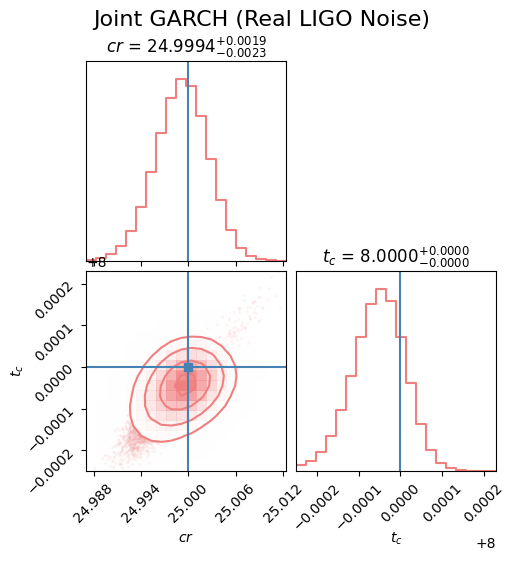


Joint GARCH Results
---------------------------
cr = 24.9992 ± 0.0022
tc = 7.999948 ± 0.000041
omega = 2.677e-06
alpha = 0.094190
beta  = 0.888096

Comparison
---------------------------
Vanilla : cr = 23.9908 ± 0.3664
          tc = 7.981918 ± 0.007940

Joint GARCH : cr = 24.9992 ± 0.0022
              tc = 7.999948 ± 0.000041


In [18]:
# =====================================================
# Joint GARCH Likelihood + MCMC
# =====================================================

import emcee
import corner
from numba import njit
from multiprocessing import Pool

# -----------------------------------------------------
# Fast GARCH Log-Likelihood
# -----------------------------------------------------

@njit
def garch_logL(residual, omega, alpha, beta):
    N = len(residual)
    sigma2 = np.empty(N)
    sigma2[0] = np.var(residual)
    if sigma2[0] < 1e-10:
        sigma2[0] = 1e-10
        logL = -0.5 * (np.log(2*np.pi*sigma2[0])+ residual[0]**2 / sigma2[0])
    for i in range(1, N):
        sigma2[i] = (omega+ alpha * residual[i-1]**2+ beta * sigma2[i-1])
        if sigma2[i] < 1e-12:
            sigma2[i] = 1e-12
        logL += (-0.5*np.log(2*np.pi*sigma2[i])-0.5*residual[i]**2/sigma2[i])
    return logL

# -----------------------------------------------------
# Joint GARCH Likelihood
# -----------------------------------------------------

def garch_log_likelihood(cr, tc, omega, alpha, beta):
    model = generate_chirp(t,A_true,cr,tc)
    model_white = spectral_whiten(model)
    model_analysis = model_white[mask]
    residual = data_analysis - model_analysis
    return garch_logL(residual,omega,alpha,beta)

# -----------------------------------------------------
# Prior
# -----------------------------------------------------

def garch_log_prior(theta):
    cr, tc, omega, alpha, beta = theta
    if not (23 < cr < 27):
        return -np.inf
    if not (7.8 < tc < 8.2):
        return -np.inf
    if not (1e-10 < omega < 1e-5):
        return -np.inf
    if not (0.01 < alpha < 0.25):
        return -np.inf
    if not (0.70 < beta < 0.98):
        return -np.inf
    if alpha + beta >= 0.99:
        return -np.inf
    return 0.0

# -----------------------------------------------------
# Posterior
# -----------------------------------------------------

def garch_log_probability(theta):
    lp = garch_log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    cr, tc, omega, alpha, beta = theta
    return lp + garch_log_likelihood(cr,tc,omega,alpha,beta)

# =====================================================
# Initialize MCMC
# =====================================================

ndim = 5
nwalkers = 40

initial = np.array([cr_true,tc_true,1e-7,0.08,0.90])

pos = []
while len(pos) < nwalkers:
    trial = np.array([
        cr_true + 0.10*np.random.randn(),
        tc_true + 0.001*np.random.randn(),
        1e-7 + 2e-8*np.random.randn(),
        0.08 + 0.01*np.random.randn(),
        0.90 + 0.01*np.random.randn()
    ])
    if np.isfinite(garch_log_prior(trial)):
        pos.append(trial)
pos = np.array(pos)

# =====================================================
# Run MCMC
# =====================================================

print("Running Joint GARCH MCMC...")

with Pool(processes=8) as pool:
    sampler_garch = emcee.EnsembleSampler(nwalkers,ndim,garch_log_probability,pool=pool)
    sampler_garch.run_mcmc(pos,15000,progress=True)
    
print("Finished.")

# =====================================================
# Extract Samples
# =====================================================

samples_garch = sampler_garch.get_chain(discard=6000,thin=10,flat=True)

print("Number of samples:", len(samples_garch))

# =====================================================
# Corner Plot
# =====================================================

figure = corner.corner(samples_garch[:, :2],labels=[r"$cr$", r"$t_c$"],truths=[cr_true, tc_true],show_titles=True,smooth=2.0,smooth1d=2.0,
    color="lightcoral",title_fmt=".4f")
figure.suptitle("Joint GARCH (Real LIGO Noise)",fontsize=16,y=1.02)
plt.show()

# =====================================================
# Results
# =====================================================

cr_est_garch = np.mean(samples_garch[:,0])
tc_est_garch = np.mean(samples_garch[:,1])

cr_std_garch = np.std(samples_garch[:,0])
tc_std_garch = np.std(samples_garch[:,1])

omega_est = np.mean(samples_garch[:,2])
alpha_est = np.mean(samples_garch[:,3])
beta_est  = np.mean(samples_garch[:,4])

print("\nJoint GARCH Results")
print("---------------------------")
print(f"cr = {cr_est_garch:.4f} ± {cr_std_garch:.4f}")
print(f"tc = {tc_est_garch:.6f} ± {tc_std_garch:.6f}")
print(f"omega = {omega_est:.3e}")
print(f"alpha = {alpha_est:.6f}")
print(f"beta  = {beta_est:.6f}")

print("\nComparison")
print("---------------------------")
print(f"Vanilla : cr = {cr_est_vanilla:.4f} ± {cr_std_vanilla:.4f}")
print(f"          tc = {tc_est_vanilla:.6f} ± {tc_std_vanilla:.6f}")

print()

print(f"Joint GARCH : cr = {cr_est_garch:.4f} ± {cr_std_garch:.4f}")
print(f"              tc = {tc_est_garch:.6f} ± {tc_std_garch:.6f}")
